Columnas disponibles: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'y_yes', 'cluster']
        age  campaign     pdays  previous  emp.var.rate  c

C:\Users\Danilo\AppData\Local\Temp\ipykernel_39276\290743050.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cluster", y="retention_rate", data=df_final[df_final["cluster"]!="GLOBAL"], palette="viridis")


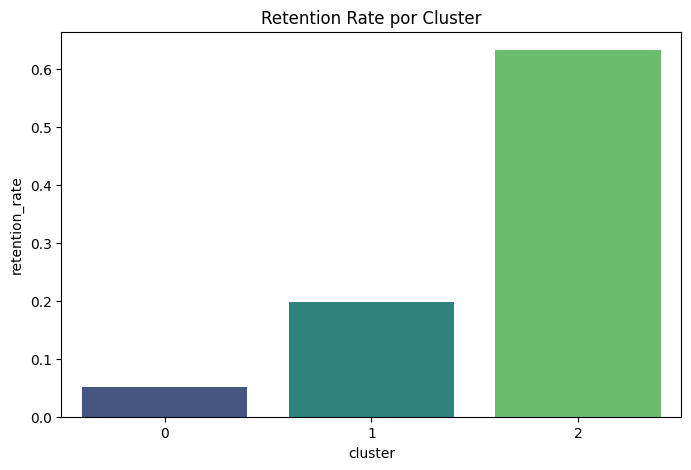

C:\Users\Danilo\AppData\Local\Temp\ipykernel_39276\290743050.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cluster", y="cross_selling_index", data=df_final[df_final["cluster"]!="GLOBAL"], palette="magma")


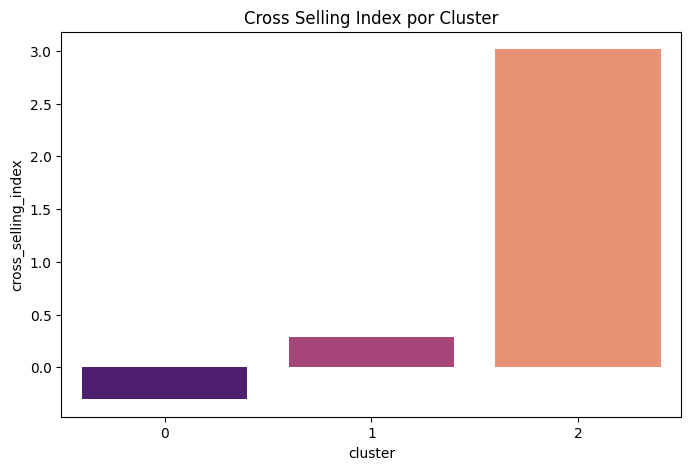

C:\Users\Danilo\AppData\Local\Temp\ipykernel_39276\290743050.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cluster", y="avg_clv", data=df_final[df_final["cluster"]!="GLOBAL"], palette="coolwarm")


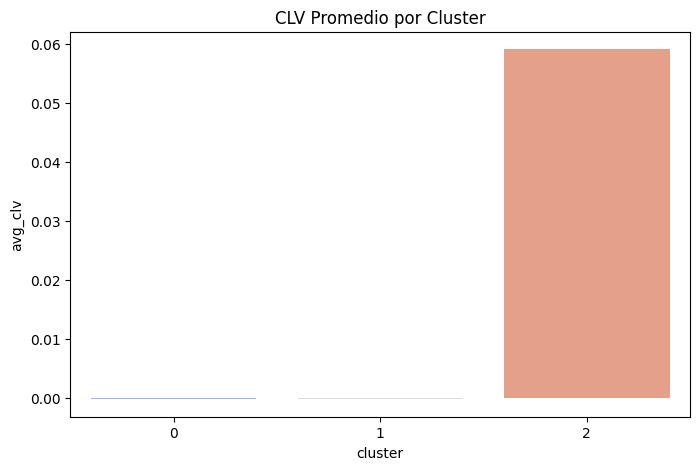

In [6]:
# === 1. Librerías ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

# Agregar src al path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), "..")))

# Importar funciones de KPIs
from src.kpis import calculate_clv, retention_rate, cross_selling_index, save_kpis

# === 2. Cargar dataset procesado (con clusters) ===
df = pd.read_csv("../data/processed/bank_clusters.csv")

# Vista rápida
print("Columnas disponibles:", df.columns.tolist())
print(df.head())

# === 3. Calcular CLV ===
# Usar 'age' como proxy de 'balance' si no existe la columna 'balance'
df = calculate_clv(df, balance_col="age", products_col="previous", factor=0.1)

# === 4. Calcular KPIs por cluster ===
df_retention = retention_rate(df, cluster_col="cluster", target_col="y_yes")
df_cross = cross_selling_index(df, cluster_col="cluster", products_col="previous")
df_kpis = df_retention.merge(df_cross, on="cluster")
df_kpis["avg_clv"] = df.groupby("cluster")["CLV"].mean().values

# === 5. Calcular KPIs globales ===
global_retention = df["y_yes"].mean()
global_cross = df["previous"].mean()
global_clv = df["CLV"].mean()

# Crear un DataFrame de KPIs globales
df_global = pd.DataFrame({
    "cluster": ["GLOBAL"],
    "retention_rate": [global_retention],
    "cross_selling_index": [global_cross],
    "avg_clv": [global_clv]
})

# === 6. Concatenar reportes ===
df_final = pd.concat([df_kpis, df_global], ignore_index=True)

print("KPIs finales:")
print(df_final)

# === 7. Guardar KPIs extendidos ===
output_path = "../outputs/reports/kpis_report.csv"
save_kpis(df_final, output_path)

# === 8. Visualizaciones ===
plt.figure(figsize=(8,5))
sns.barplot(x="cluster", y="retention_rate", data=df_final[df_final["cluster"]!="GLOBAL"], palette="viridis")
plt.title("Retention Rate por Cluster")
plt.savefig("../outputs/reports/retention_rate.png")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="cluster", y="cross_selling_index", data=df_final[df_final["cluster"]!="GLOBAL"], palette="magma")
plt.title("Cross Selling Index por Cluster")
plt.savefig("../outputs/reports/cross_selling.png")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="cluster", y="avg_clv", data=df_final[df_final["cluster"]!="GLOBAL"], palette="coolwarm")
plt.title("CLV Promedio por Cluster")
plt.savefig("../outputs/reports/avg_clv.png")
plt.show()
